# Realistic dataset 

In [34]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import glob
import os

In [35]:
# --- 1. Global Academic Style Configuration ---
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 13,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'lines.linewidth': 2,
    'lines.markersize': 6,
    'figure.dpi': 300,
    'savefig.bbox': 'tight',
})

In [36]:
plot_path = f"../results/Realistic_dataset"
os.makedirs(plot_path, exist_ok=True)

## Label error + ACC vs. alpha (d_MLP fix)

In [37]:
# 100
run_id_S = "20251217_1517"
run_id_tied = "20251217_0723"
run_id_untied = "20251218_1108"
run_id_S_sym = "20251217_2250"

# 10
# run_id_S = "20251219_0836"
# run_id_tied = "20251221_0849"
# run_id_untied = "20251220_1538"
# run_id_S_sym = "20251220_0919"

run_dir_S = f"../results/run_{run_id_S}/"
config_path_S = f"../results/run_{run_id_S}/config.csv"
base_path_S = f"../results/run_{run_id_S}/summary.csv"

run_dir_tied = f"../results/run_{run_id_tied}/"
config_path_tied = f"../results/run_{run_id_tied}/config.csv"
base_path_tied = f"../results/run_{run_id_tied}/summary.csv"

run_dir_untied = f"../results/run_{run_id_untied}/"
config_path_untied = f"../results/run_{run_id_untied}/config.csv"
base_path_untied = f"../results/run_{run_id_untied}/summary.csv"

run_dir_S_sym = f"../results/run_{run_id_S_sym}/"
config_path_S_sym = f"../results/run_{run_id_S_sym}/config.csv"
base_path_S_sym = f"../results/run_{run_id_S_sym}/summary.csv"

# --- Unfactorized ---
df_S = pd.read_csv(base_path_S)
print(f"✅ Summary loaded ({len(df_S)} rows) from {base_path_S}")
display(df_S.head())

df_S_sym = pd.read_csv(base_path_S_sym)
print(f"✅ Summary loaded ({len(df_S_sym)} rows) from {base_path_S_sym}")
display(df_S_sym.head())

# --- Tied ---
df_tied = pd.read_csv(base_path_tied)
print(f"✅ Summary loaded ({len(df_tied)} rows) from {base_path_tied}")
display(df_tied.head())

# --- Untied ---
df_untied = pd.read_csv(base_path_untied)
print(f"✅ Summary loaded ({len(df_untied)} rows) from {base_path_untied}")
display(df_untied.head())
plt.rcParams.update({'font.size': 12}) 

plt.rcParams.update({'font.size': 12}) 

✅ Summary loaded (15 rows) from ../results/run_20251217_1517/summary.csv


,alpha,MLP_dim,rho,p_ft,lamda,label_err_mean,label_err_std,train_data_mean,train_reg_mean,train_total_mean,...,acc_test_mean,acc_test_std,acc_fine_tune_mean,acc_fine_tune_std,acc_train_mean,acc_train_std,rank_before_mean,rank_before_std,rank_after_mean,rank_after_std
0,0.010000,100,1.0,0.0,0.00010,0.784717,0.020970,0.000047,0.000023,0.000070,...,0.215283,0.020970,NaN,NaN,0.825830,0.217864,100.0,0.000000,100.0,0.000000
1,0.151429,100,1.0,0.0,0.00010,0.515765,0.049527,0.000125,0.000020,0.000145,...,0.484235,0.049527,NaN,NaN,0.531923,0.051794,98.5,0.707107,98.5,0.707107
2,0.080714,100,1.0,0.0,0.00010,0.539913,0.095058,0.000112,0.000024,0.000136,...,0.460087,0.095058,NaN,NaN,0.565409,0.136588,98.8,1.398412,98.8,1.398412
3,0.222143,100,1.0,0.0,0.00001,0.442643,0.066018,0.000105,0.000009,0.000113,...,0.557357,0.066018,NaN,NaN,0.605441,0.068364,99.5,0.527046,99.5,0.527046
4,0.434286,100,1.0,0.0,0.00010,0.430325,0.070167,0.000113,0.000024,0.000137,...,0.569675,0.070167,NaN,NaN,0.579738,0.067375,97.9,1.595131,97.9,1.595131


✅ Summary loaded (15 rows) from ../results/run_20251217_2250/summary.csv


,alpha,MLP_dim,rho,p_ft,lamda,label_err_mean,label_err_std,train_data_mean,train_reg_mean,train_total_mean,...,acc_test_mean,acc_test_std,acc_fine_tune_mean,acc_fine_tune_std,acc_train_mean,acc_train_std,rank_before_mean,rank_before_std,rank_after_mean,rank_after_std
0,0.010000,100,1.0,0.0,0.00100,0.774327,0.018129,0.000087,0.000072,0.000160,...,0.225673,0.018129,NaN,NaN,0.730721,0.071594,96.8,1.135292,96.8,1.135292
1,0.080714,100,1.0,0.0,0.00001,0.597375,0.109158,0.000131,0.000008,0.000139,...,0.402625,0.109158,NaN,NaN,0.513797,0.150480,95.1,0.994429,95.1,0.994429
2,0.151429,100,1.0,0.0,0.00010,0.555030,0.045209,0.000133,0.000019,0.000153,...,0.444970,0.045209,NaN,NaN,0.503174,0.058223,98.0,0.816497,98.0,0.816497
3,0.222143,100,1.0,0.0,0.00010,0.517062,0.065567,0.000138,0.000020,0.000158,...,0.482938,0.065567,NaN,NaN,0.493935,0.057325,97.8,1.398412,97.8,1.398412
4,0.292857,100,1.0,0.0,0.00010,0.512725,0.107684,0.000136,0.000020,0.000155,...,0.487275,0.107684,NaN,NaN,0.496163,0.129127,97.2,1.813529,97.2,1.813529


✅ Summary loaded (15 rows) from ../results/run_20251217_0723/summary.csv


,alpha,MLP_dim,rho,p_ft,lamda,label_err_mean,label_err_std,train_data_mean,train_reg_mean,train_total_mean,...,acc_test_mean,acc_test_std,acc_fine_tune_mean,acc_fine_tune_std,acc_train_mean,acc_train_std,rank_before_mean,rank_before_std,rank_after_mean,rank_after_std
0,0.010000,100,1.0,0.0,0.00010,0.605285,0.009138,0.000008,0.000032,0.000040,...,0.394715,0.009138,NaN,NaN,0.983908,0.013707,98.6,1.349897,98.6,1.349897
1,0.151429,100,1.0,0.0,0.00001,0.143718,0.030573,0.000036,0.000013,0.000049,...,0.856282,0.030573,NaN,NaN,0.874512,0.017826,94.5,6.835366,94.5,6.835366
2,0.080714,100,1.0,0.0,0.00001,0.197515,0.067377,0.000038,0.000012,0.000050,...,0.802485,0.067377,NaN,NaN,0.848241,0.121434,93.3,9.202053,93.3,9.202053
3,0.363571,100,1.0,0.0,0.00001,0.143830,0.057495,0.000043,0.000013,0.000056,...,0.856170,0.057495,NaN,NaN,0.843735,0.091440,91.6,8.946756,91.6,8.946756
4,0.222143,100,1.0,0.0,0.00001,0.162127,0.090163,0.000042,0.000013,0.000054,...,0.837873,0.090163,NaN,NaN,0.847582,0.129814,92.2,9.028350,92.2,9.028350


✅ Summary loaded (15 rows) from ../results/run_20251218_1108/summary.csv


,alpha,MLP_dim,rho,p_ft,lamda,label_err_mean,label_err_std,train_data_mean,train_reg_mean,train_total_mean,...,acc_train_mean,acc_train_std,rank_Q_before_mean,rank_Q_before_std,rank_K_before_mean,rank_K_before_std,rank_Q_after_mean,rank_Q_after_std,rank_K_after_mean,rank_K_after_std
0,0.010000,100,1.0,0.0,0.00001,0.767183,0.012330,0.000015,0.000016,0.000031,...,0.944109,0.057144,100.0,0.000000,99.9,0.316228,100.0,0.000000,99.9,0.316228
1,0.080714,100,1.0,0.0,0.00010,0.463255,0.059917,0.000087,0.000042,0.000129,...,0.678222,0.099034,85.5,8.834906,84.8,9.295160,85.5,8.834906,84.8,9.295160
2,0.151429,100,1.0,0.0,0.00010,0.338693,0.082759,0.000086,0.000040,0.000126,...,0.691667,0.097565,83.8,7.004760,84.0,7.133645,83.8,7.004760,84.0,7.133645
3,0.292857,100,1.0,0.0,0.00010,0.338433,0.052884,0.000094,0.000040,0.000134,...,0.672373,0.056150,76.4,9.593980,76.1,8.332667,76.4,9.593980,76.1,8.332667
4,0.222143,100,1.0,0.0,0.00001,0.392842,0.094825,0.000091,0.000012,0.000102,...,0.651631,0.089628,93.2,7.656515,92.0,9.545214,93.2,7.656515,92.0,9.545214


✅ Saved plot: ../results/Realistic_dataset/label_error_vs_alpha_MLP100_run20251217_1517.png


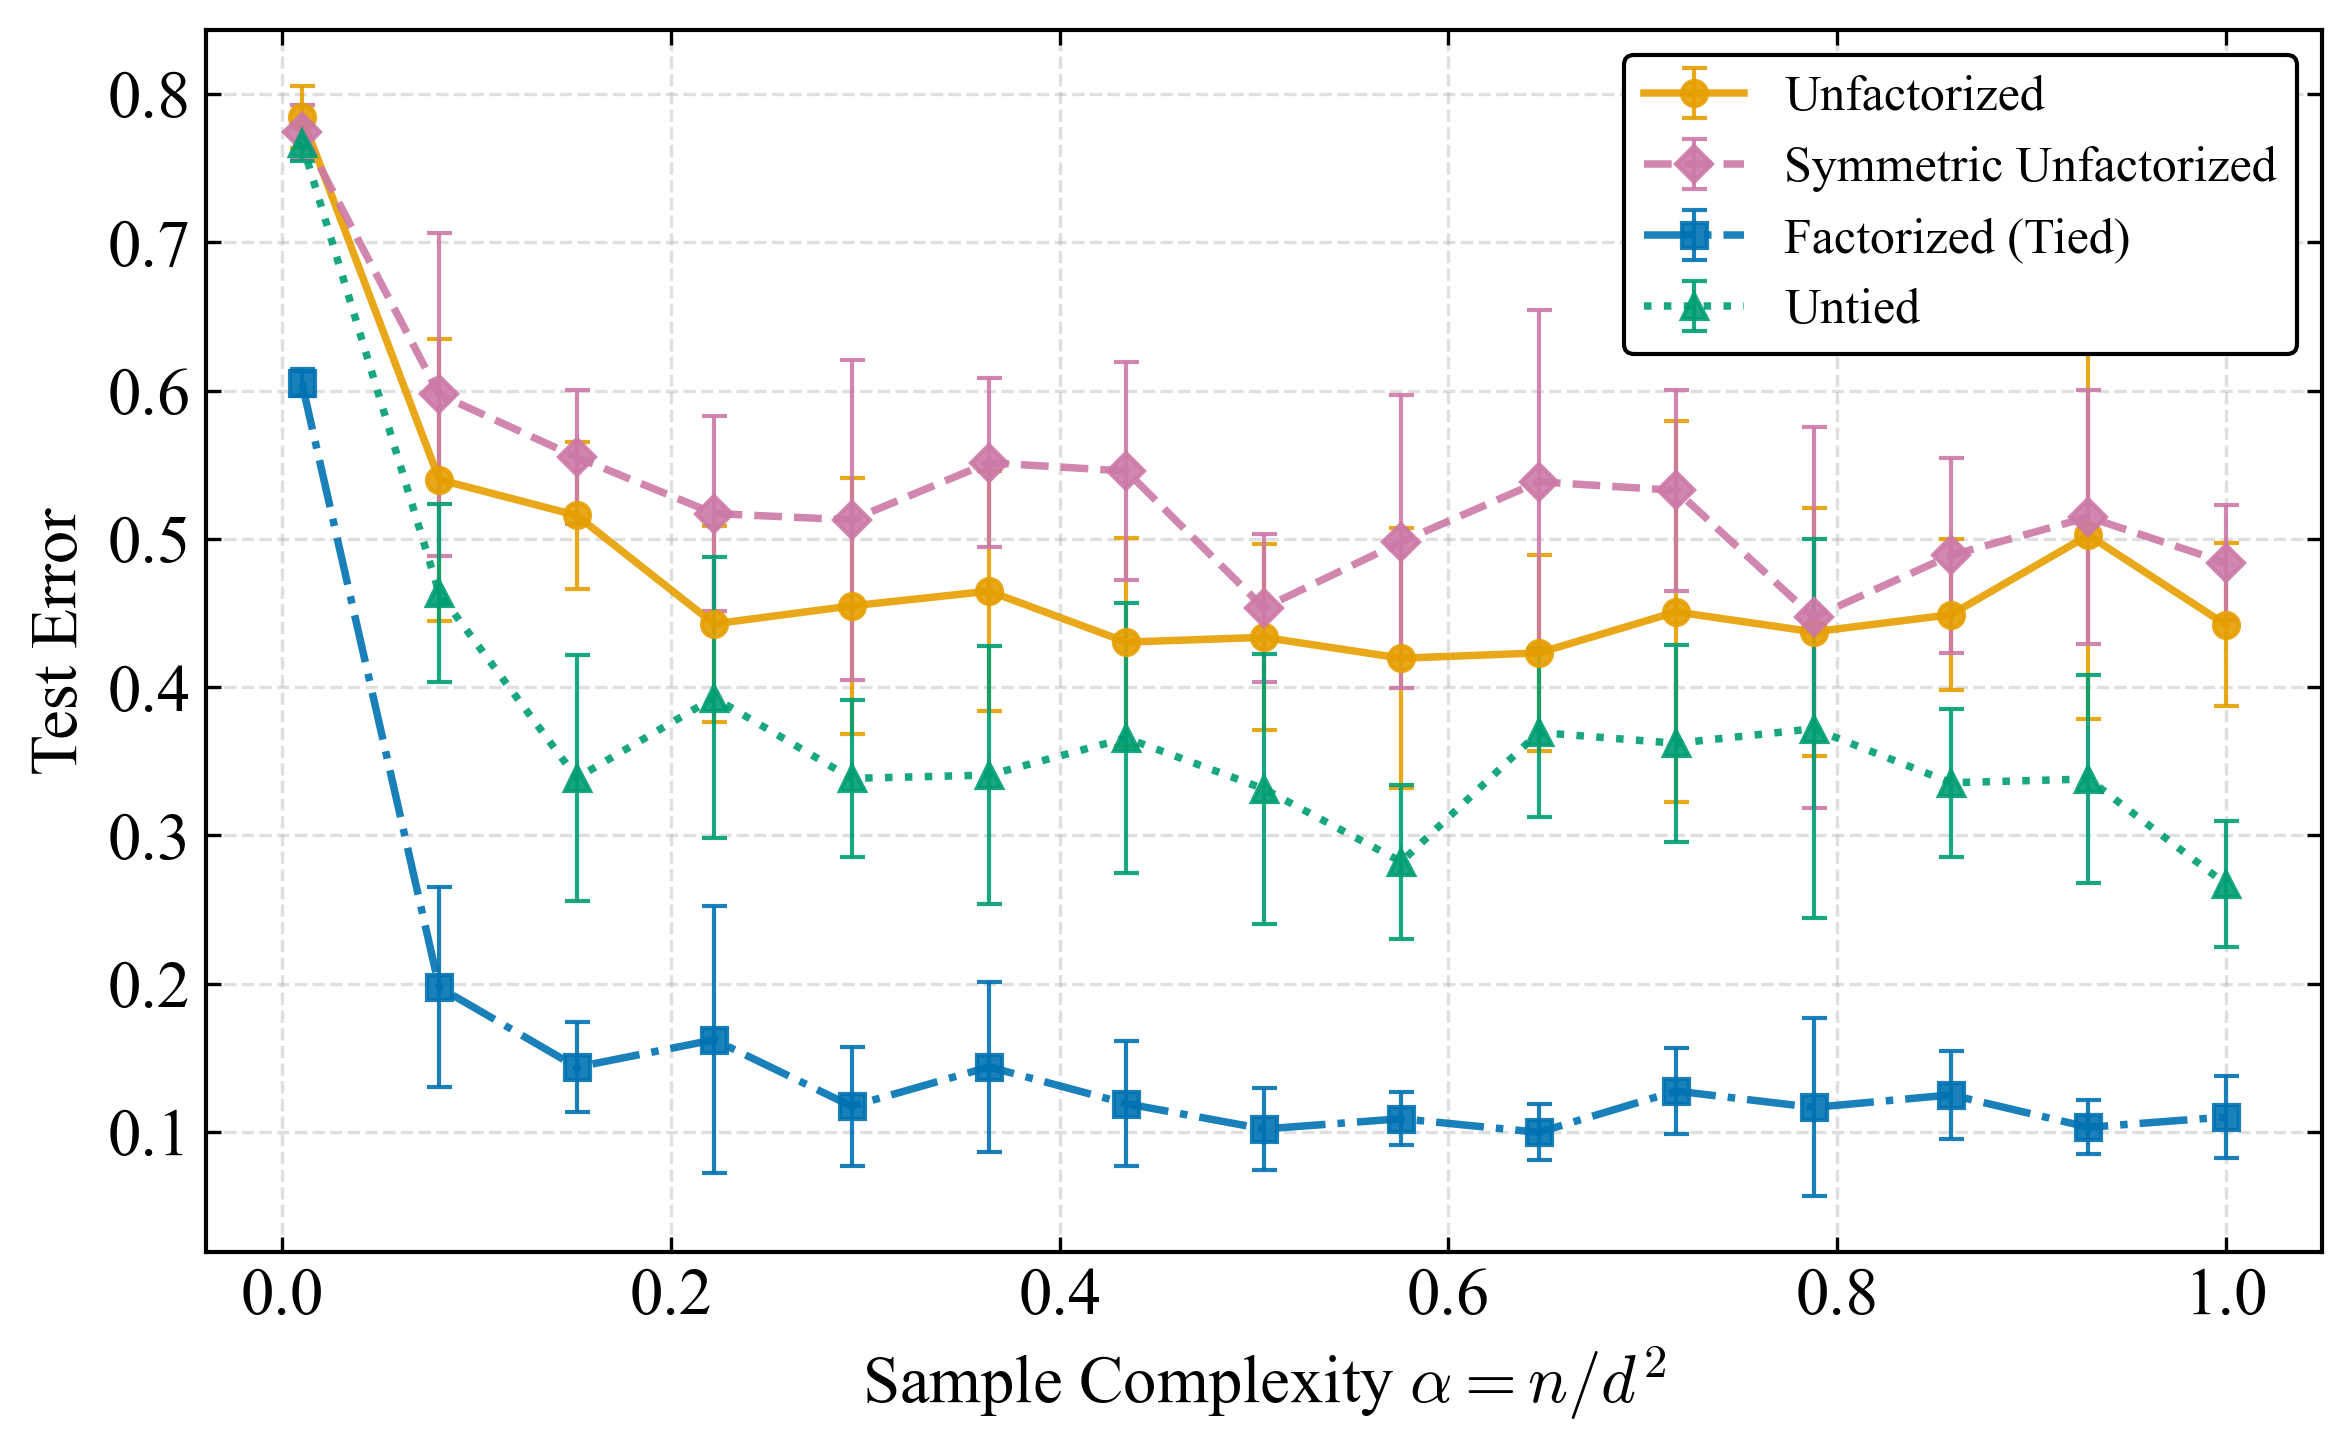

✅ Saved plot: ../results/Realistic_dataset/test_accuracy_vs_alpha_MLP100_run20251217_1517.png


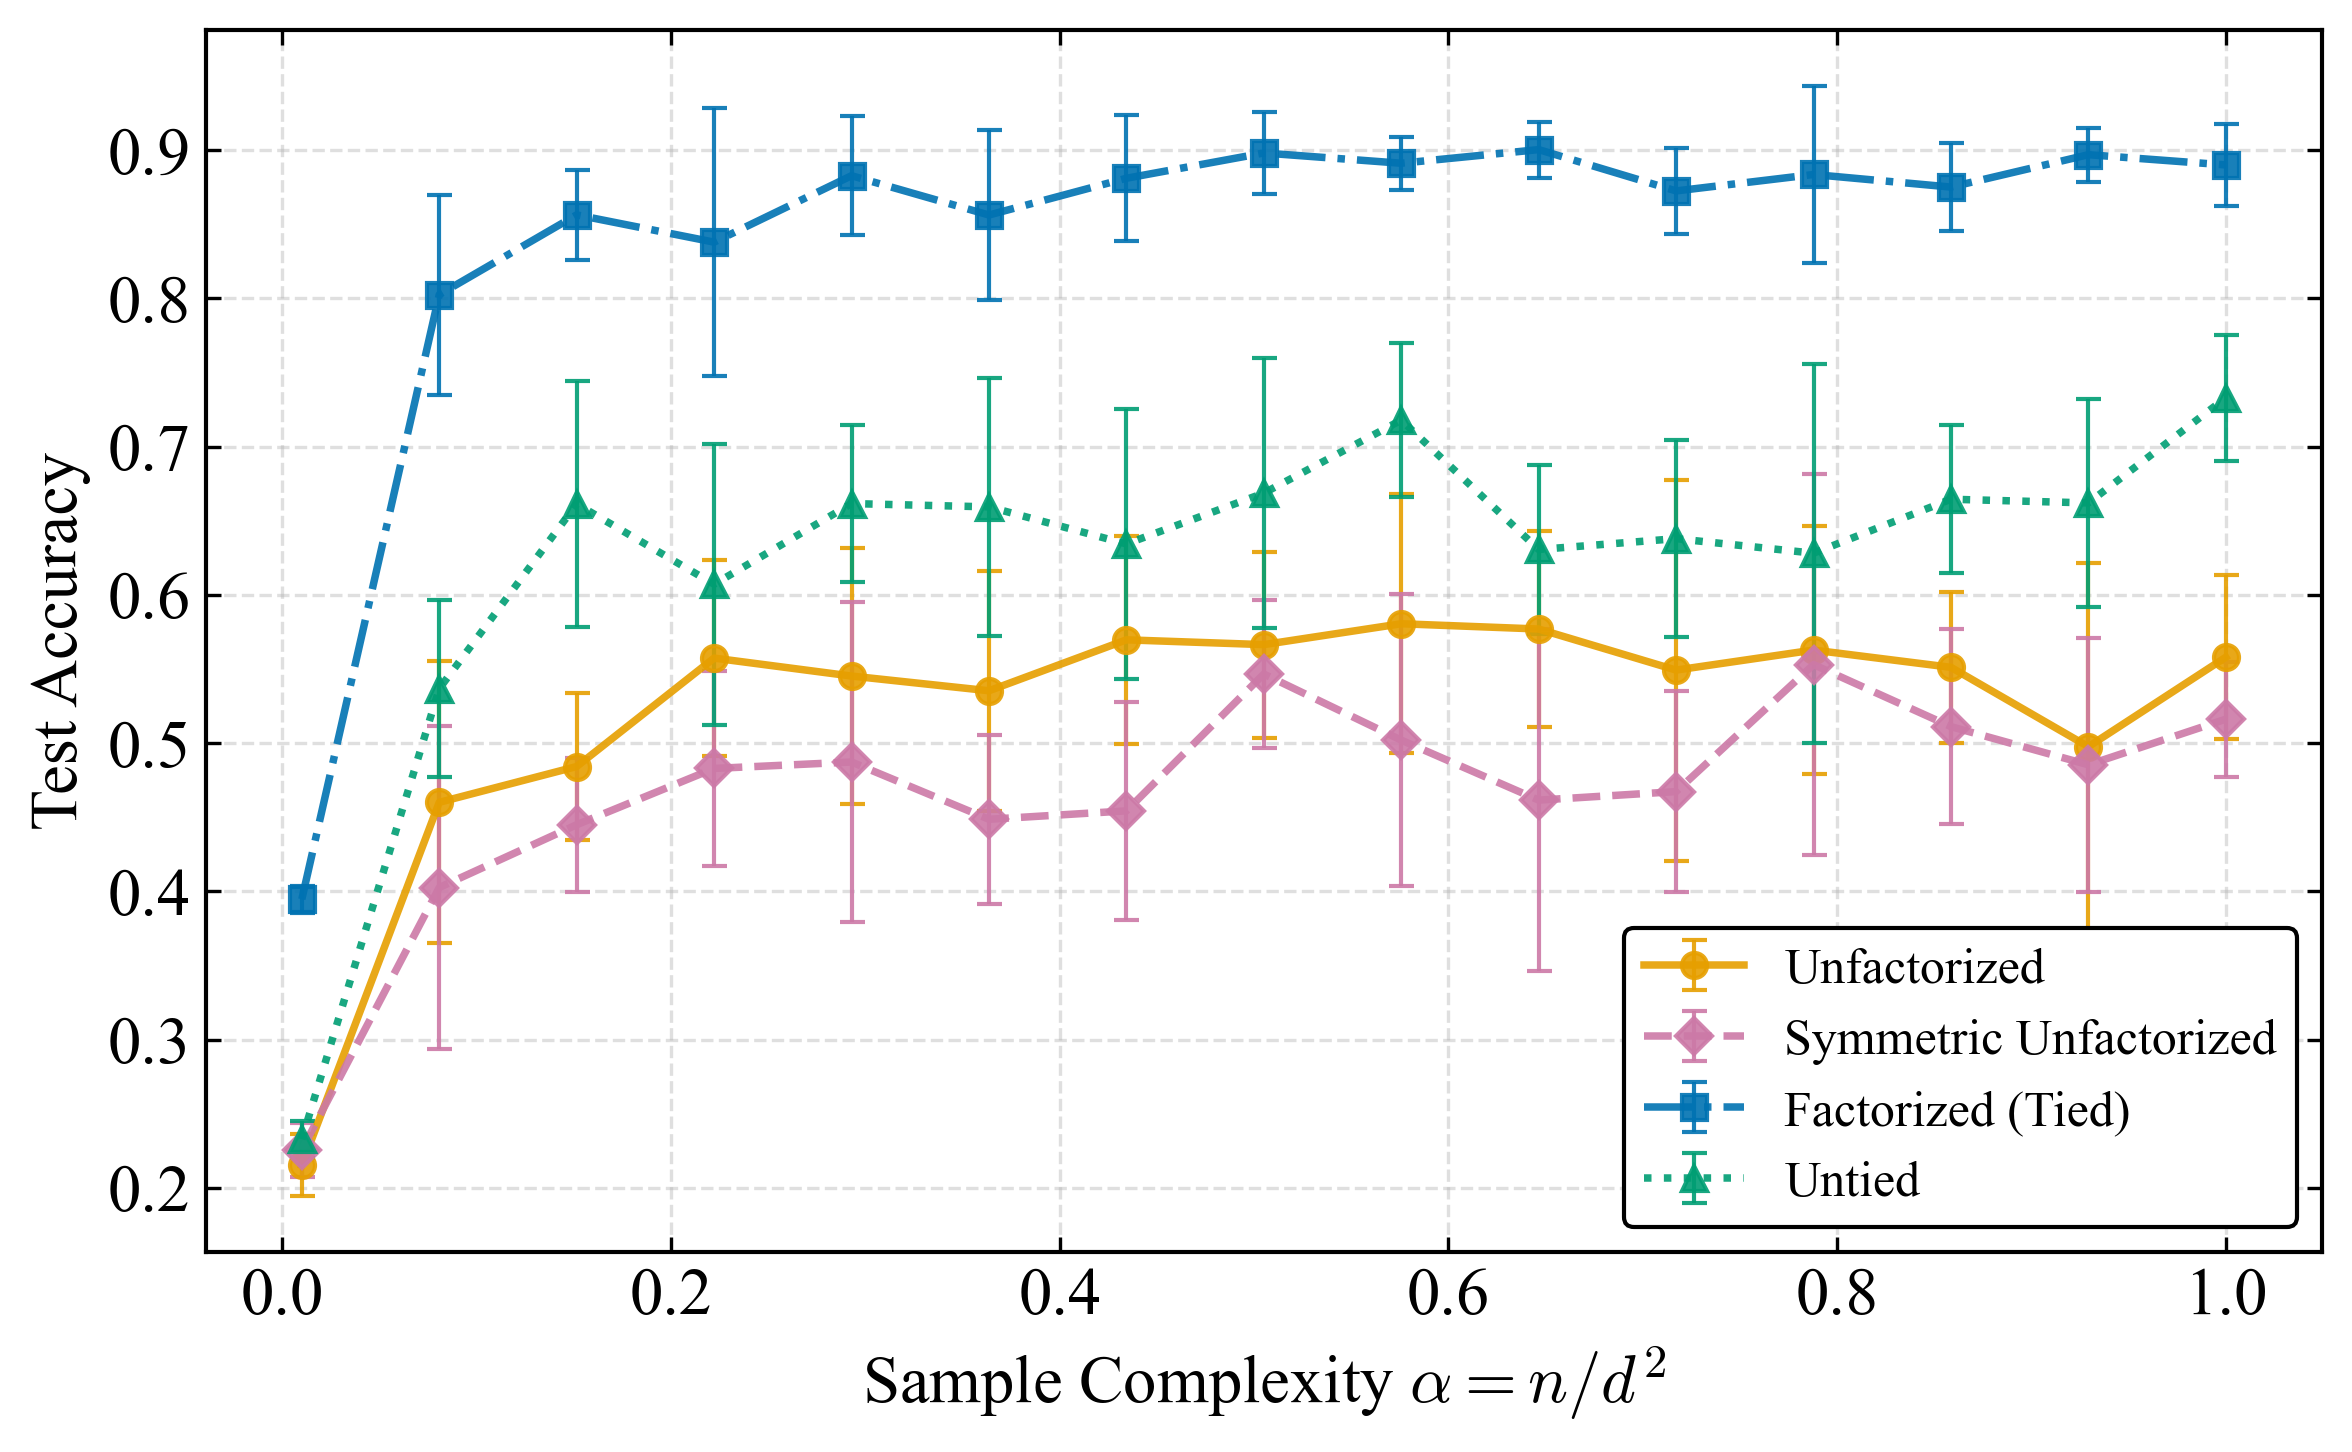

In [38]:
# --- 2. Préparation des données ---
MLP_target = 100  # <-- Choisis ton d_MLP

# Vérification et filtrage pour les 3 DataFrames
if 'df_S' in locals() and 'df_tied' in locals() and 'df_untied' in locals():
    subset_S = df_S[df_S["MLP_dim"] == MLP_target].sort_values("alpha")
    subset_tied = df_tied[df_tied["MLP_dim"] == MLP_target].sort_values("alpha")
    subset_untied = df_untied[df_untied["MLP_dim"] == MLP_target].sort_values("alpha")
    subset_S_sym = df_S_sym[df_S_sym["MLP_dim"] == MLP_target].sort_values("alpha")
else:
    print("⚠️ DataFrames 'df_S', 'df_tied' or 'df_untied' not found.")
    subset_S, subset_tied, subset_untied, subset_S_sym  = pd.DataFrame(), pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

def plot_compare_vs_alpha(
    data_s, data_tied, data_untied, data_S_sym,
    y_col, y_err_col, 
    ylabel, filename, 
    loc_legend='best'
):
    fig, ax = plt.subplots(figsize=(8, 5)) # Un peu plus large pour la légende

    # --- CONFIGURATION DES STYLES ---
    # On définit des styles contrastés pour chaque catégorie
    styles = [
        # Label, Color, Marker, LineStyle
        ("Unfactorized", "#E69F00", "o", "-"),       # Orange, Cercle, Plein
        ("Symmetric Unfactorized", "#CC79A7", "D", "--"), # Rose/Mauve, Diamant, Tirets
        ("Factorized (Tied)", "#0072B2", "s", "-."),  # Bleu, Carré, Mixte
        ("Untied", "#009E73", "^", ":"), # Vert, Triangle, Pointillés
    ]
    
    datasets = [data_s, data_S_sym, data_tied, data_untied]

    for data, (label, color, marker, ls) in zip(datasets, styles):
        if not data.empty:
            ax.errorbar(
                data["alpha"],
                data[y_col],
                yerr=data.get(y_err_col, 0),
                label=label,
                color=color,
                marker=marker,
                linestyle=ls,
                markersize=6,      # Marqueurs légèrement plus grands
                linewidth=1.8,     # Ligne un peu plus épaisse
                capsize=3,         # Petites barres au bout des erreurs
                elinewidth=1,
                alpha=0.9
            )

    # --- Labels et Style ---
    ax.set_xlabel(r"Sample Complexity $\alpha = n/d^2$", fontsize=16)
    ax.set_ylabel(ylabel, fontsize=16)
    
    # Grille légère pour la lecture des valeurs
    ax.grid(True, linestyle='--', alpha=0.4)

    # --- STYLE BOÎTE ---
    ax.set_axisbelow(True)
    ax.tick_params(direction='in', top=True, right=True, which='both')
    
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)

    # Légende optimisée
    ax.legend(frameon=True, fontsize=12, edgecolor='black', framealpha=1.0, loc=loc_legend)
    
    plt.tight_layout()
    
    # Sauvegarde
    if not os.path.exists(plot_path): os.makedirs(plot_path)
    save_full = os.path.join(plot_path, filename)
    plt.savefig(save_full, dpi=300, bbox_inches='tight')
    print(f"✅ Saved plot: {save_full}")
    plt.show()

# --- 4. Exécution ---

if not subset_S.empty and not subset_tied.empty and not subset_untied.empty:
    
    # Récupération d'un ID de run pour le nom de fichier (optionnel)
    run_suffix = f"_run{run_id_S}" if 'run_id_S' in locals() else ""

    # -------------------- LABEL ERROR --------------------
    plot_compare_vs_alpha(
        subset_S, subset_tied, subset_untied, subset_S_sym,
        y_col="label_err_mean",
        y_err_col="label_err_std",
        ylabel="Test Error",
        filename=f"label_error_vs_alpha_MLP{MLP_target}{run_suffix}.png",
        loc_legend="upper right" 
    )

    # -------------------- TEST ACCURACY --------------------
    plot_compare_vs_alpha(
        subset_S, subset_tied, subset_untied, subset_S_sym,
        y_col="acc_test_mean",
        y_err_col="acc_test_std",
        ylabel="Test Accuracy",
        filename=f"test_accuracy_vs_alpha_MLP{MLP_target}{run_suffix}.png",
        loc_legend="lower right"
    )

else:
    print(f"⚠️ One of the subsets is empty for MLP_dim = {MLP_target}")

✅ Graphe sauvegardé : ../results/Realistic_dataset/comparison_ranks_MLP100.png


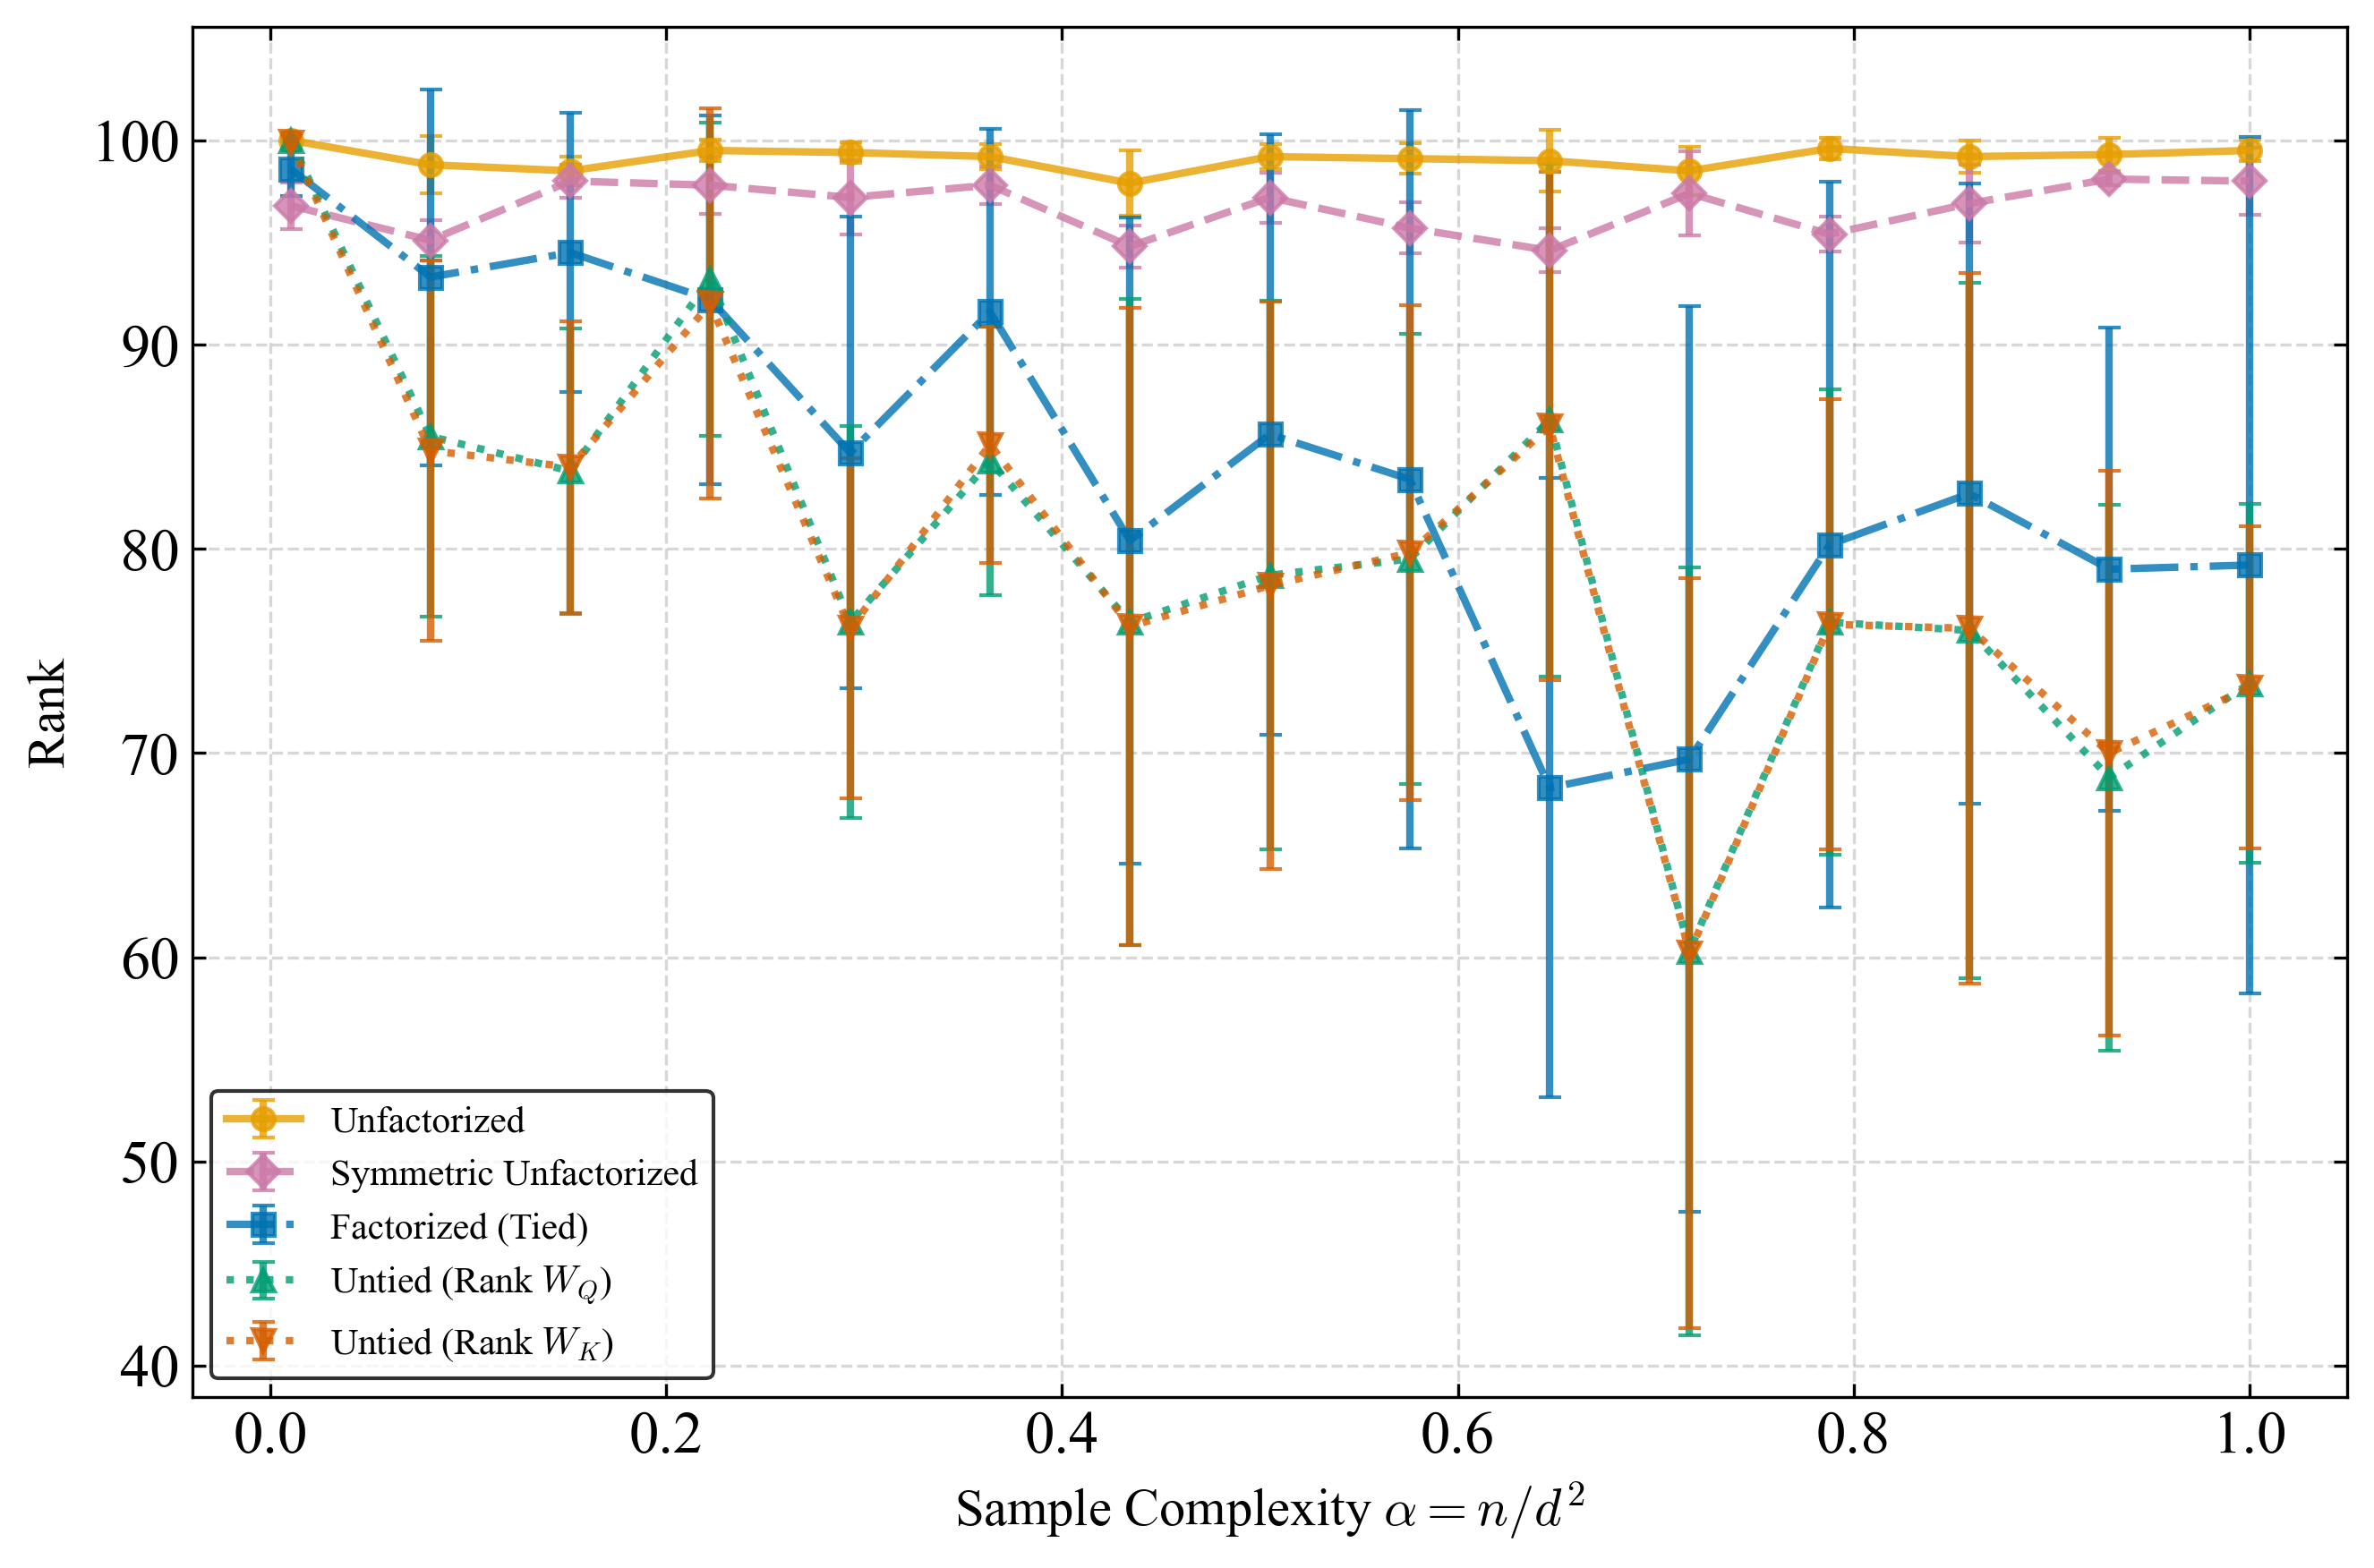

In [40]:
# --- 2. Préparation des sous-ensembles ---
# On trie par alpha pour éviter les zigzags sur le graphique
subset_S = df_S[df_S["MLP_dim"] == MLP_target].sort_values("alpha")
subset_S_sym = df_S_sym[df_S_sym["MLP_dim"] == MLP_target].sort_values("alpha")
subset_tied = df_tied[df_tied["MLP_dim"] == MLP_target].sort_values("alpha")
subset_untied = df_untied[df_untied["MLP_dim"] == MLP_target].sort_values("alpha")

# --- 3. Définition de la fonction de plot dynamique ---
def plot_ranks_comparison(configs, filename="rank_evolution.png"):
    fig, ax = plt.subplots(figsize=(9, 6))

    for cfg in configs:
        data = cfg["data"]
        if not data.empty:
            ax.errorbar(
                data["alpha"],
                data[cfg["y_col"]],
                yerr=data.get(cfg["y_err_col"], 0),
                label=cfg["label"],
                color=cfg["color"],
                marker=cfg["marker"],
                linestyle=cfg["ls"],
                markersize=6,
                linewidth=2,
                capsize=3,
                alpha=0.8
            )

    # Styling
    ax.set_xlabel(r"Sample Complexity $\alpha = n/d^2$", fontsize=14)
    ax.set_ylabel("Rank", fontsize=14)
    # ax.set_title(f"Numerical Rank Evolution (MLP dim = {MLP_target})", fontsize=15)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.tick_params(direction='in', top=True, right=True)
    
    # Légende à l'extérieur ou optimisée
    ax.legend(frameon=True, fontsize=10, edgecolor='black', loc='best')
    
    plt.tight_layout()
    save_full = os.path.join(plot_path, filename)
    plt.savefig(save_full, dpi=300, bbox_inches='tight')
    print(f"✅ Graphe sauvegardé : {save_full}")
    plt.show()

# --- 4. Configuration des courbes (Noms de colonnes spécifiques) ---
rank_configs = [
    {
        "data": subset_S, "label": "Unfactorized", 
        "y_col": "rank_before_mean", "y_err_col": "rank_before_std", 
        "color": "#E69F00", "marker": "o", "ls": "-"
    },
    {
        "data": subset_S_sym, "label": "Symmetric Unfactorized", 
        "y_col": "rank_before_mean", "y_err_col": "rank_before_std", 
        "color": "#CC79A7", "marker": "D", "ls": "--"
    },
    {
        "data": subset_tied, "label": "Factorized (Tied)", 
        "y_col": "rank_before_mean", "y_err_col": "rank_before_std", 
        "color": "#0072B2", "marker": "s", "ls": "-."
    },
    # Cas Untied : superposition des rangs de Q et K
    {
        "data": subset_untied, "label": "Untied (Rank $W_Q$)", 
        "y_col": "rank_Q_before_mean", "y_err_col": "rank_Q_before_std", 
        "color": "#009E73", "marker": "^", "ls": ":"
    },
    {
        "data": subset_untied, "label": "Untied (Rank $W_K$)", 
        "y_col": "rank_K_before_mean", "y_err_col": "rank_K_before_std", 
        "color": "#D55E00", "marker": "v", "ls": ":"
    }
]

# --- 5. Lancement du plot ---
plot_ranks_comparison(rank_configs, filename=f"comparison_ranks_MLP{MLP_target}.png")